# Task 4: Unsupervised Learning (PCA + K-Means Clustering)
### Customer Segmentation

**Goal:** Apply Unsupervised Learning techniques — K-Means Clustering for customer segmentation, and Principal Component Analysis (PCA) for dimensionality reduction and visualization.

**Dataset:** Mall Customer Segmentation Dataset (Kaggle) — `Mall_Customers.csv`

**Difficulty:** Hard

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline
sns.set_style('whitegrid')

## Step 2: Load and Explore the Dataset

> Download `Mall_Customers.csv` from Kaggle: [Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python) and place it in the project folder.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Step 3: Exploratory Data Analysis

### 3.1 Gender Distribution

C:\Users\ULC\AppData\Local\Temp\ipykernel_13568\3658001479.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='pastel')


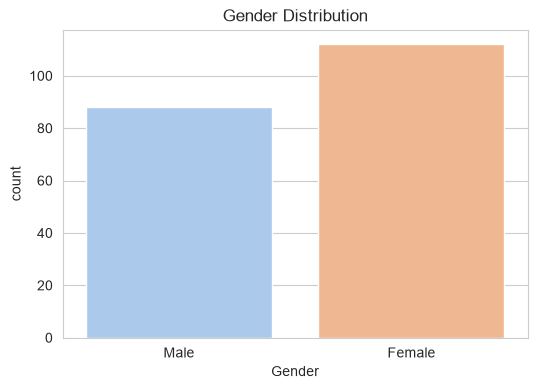

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df, palette='pastel')
plt.title('Gender Distribution')
plt.savefig('1_gender_distribution.png')
plt.show()

### 3.2 Age, Income, and Spending Score Distributions

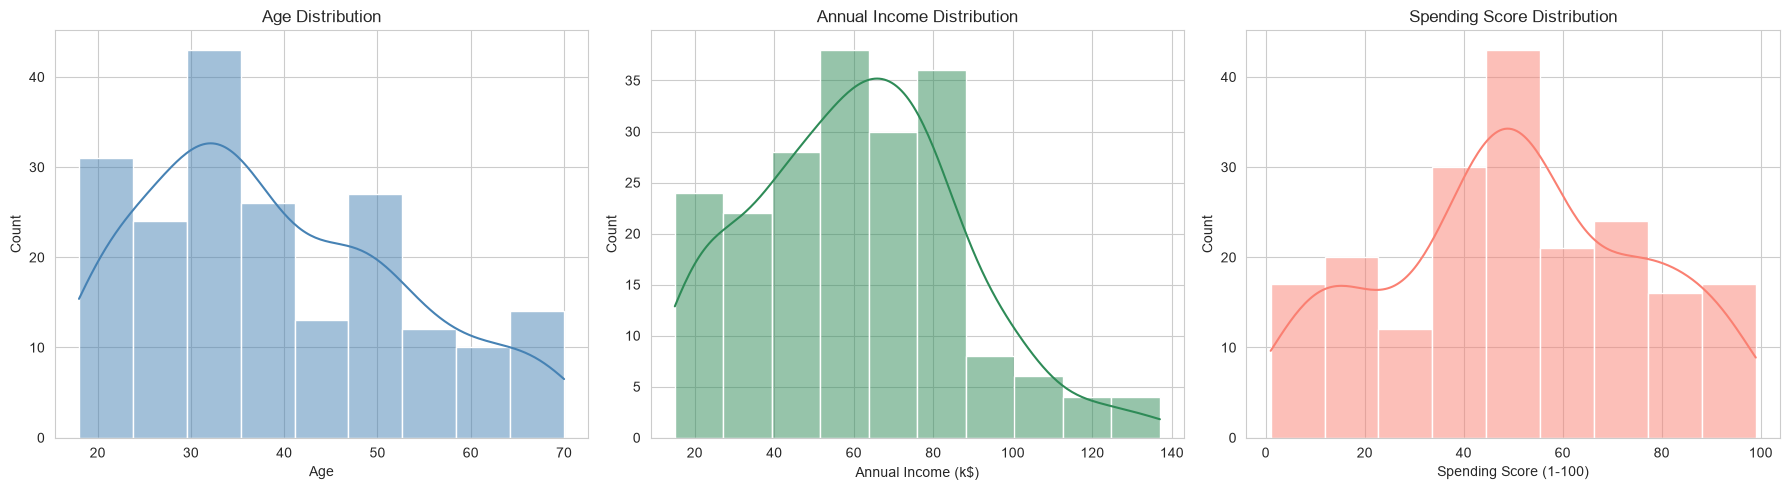

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.savefig('2_feature_distributions.png')
plt.show()

### 3.3 Annual Income vs Spending Score
This is the key relationship we'll cluster on.

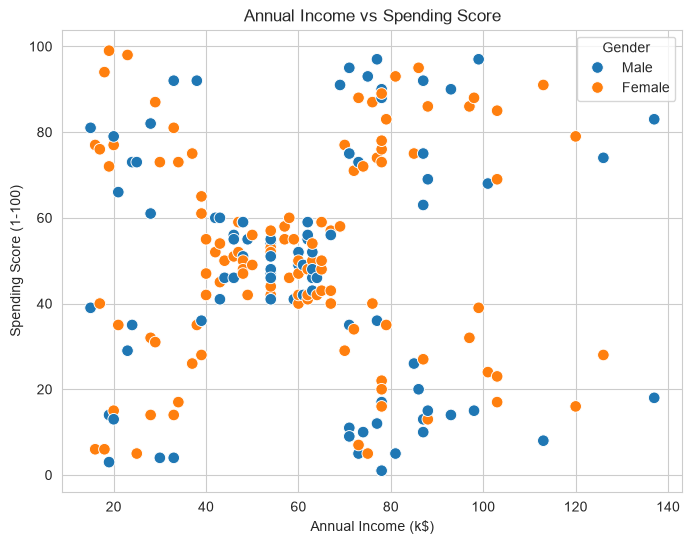

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender', s=70)
plt.title('Annual Income vs Spending Score')
plt.savefig('3_income_vs_spending.png')
plt.show()

### 3.4 Correlation Heatmap

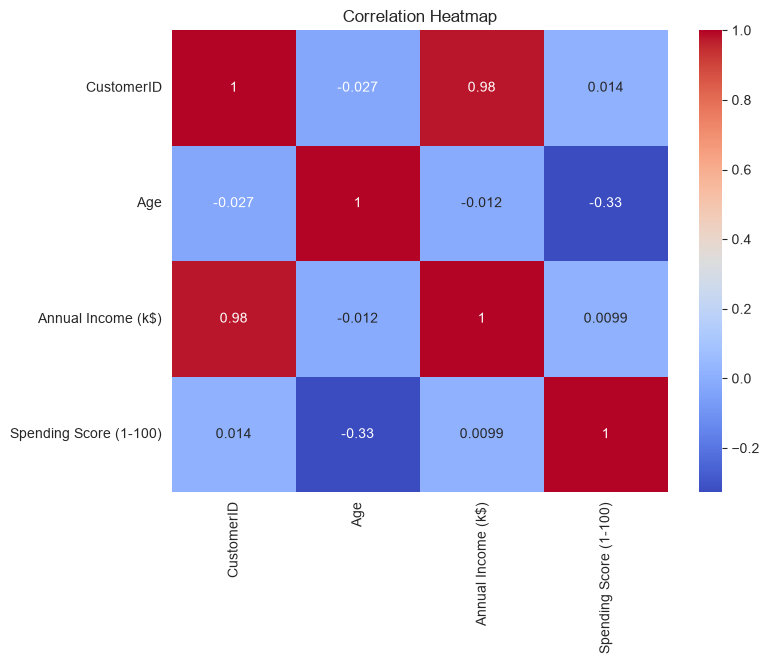

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('4_correlation_heatmap.png')
plt.show()

## Step 4: Data Preprocessing

### 4.1 Encode Categorical Feature (Gender)

In [11]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


### 4.2 Select Features for Clustering

In [12]:
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender']
X = df[features]
X.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


### 4.3 Feature Scaling
K-Means is distance-based, so scaling is essential — otherwise features with larger ranges (like Income) dominate the clustering.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148,  1.12815215],
       [-1.28103541, -1.73899919,  1.19570407,  1.12815215],
       [-1.3528021 , -1.70082976, -1.71591298, -0.88640526],
       [-1.13750203, -1.70082976,  1.04041783, -0.88640526],
       [-0.56336851, -1.66266033, -0.39597992, -0.88640526]])

## Step 5: Finding the Optimal Number of Clusters

### 5.1 Elbow Method

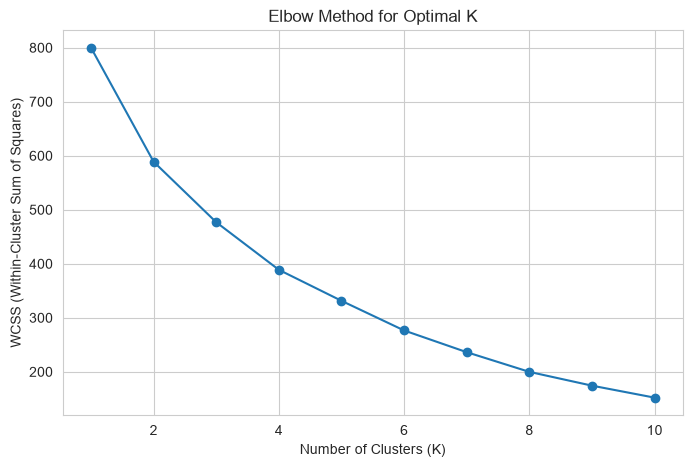

In [14]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.savefig('5_elbow_method.png')
plt.show()

### 5.2 Silhouette Score
A second method to validate the best K — higher silhouette score means better-defined clusters.

K=2: Silhouette Score = 0.2518
K=3: Silhouette Score = 0.2595
K=4: Silhouette Score = 0.2984
K=5: Silhouette Score = 0.3041
K=6: Silhouette Score = 0.3311
K=7: Silhouette Score = 0.3574
K=8: Silhouette Score = 0.3880
K=9: Silhouette Score = 0.4031
K=10: Silhouette Score = 0.4208


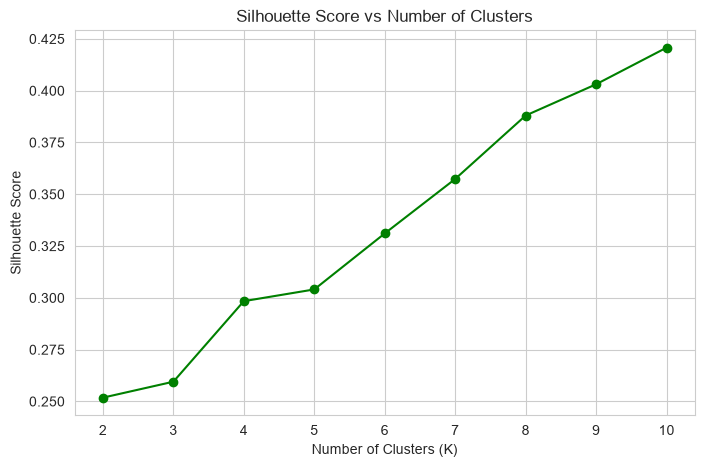

In [15]:
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}: Silhouette Score = {score:.4f}')

plt.figure(figsize=(8,5))
plt.plot(list(K_range_sil), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.savefig('6_silhouette_scores.png')
plt.show()

## Step 6: Apply K-Means Clustering

Based on the Elbow Method and Silhouette Score, choose the optimal K (commonly **K=5** for this dataset).

In [16]:
optimal_k = 5  # Update this based on your elbow/silhouette plots

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,3
3,4,0,23,16,77,3
4,5,0,31,17,40,3


In [17]:
# Cluster sizes
df['Cluster'].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

## Step 7: Visualize Clusters (Income vs Spending Score)

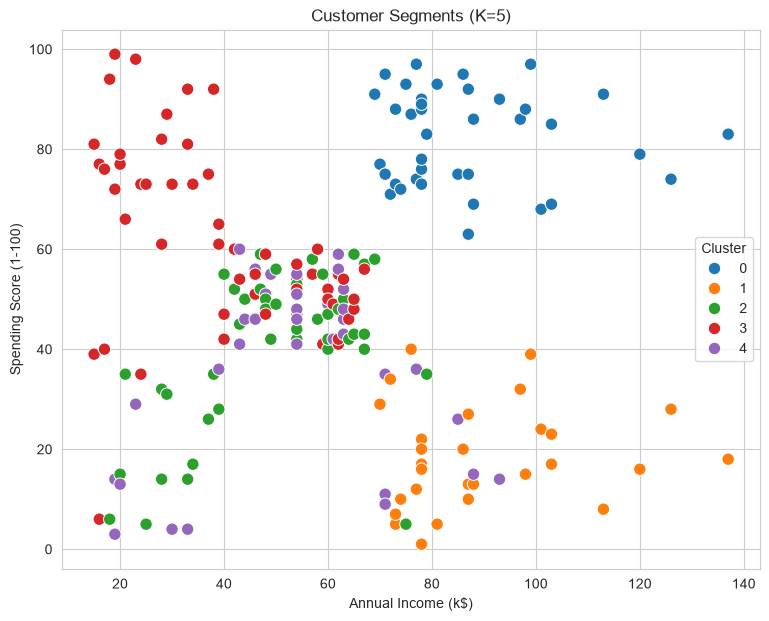

In [18]:
plt.figure(figsize=(9,7))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster',
                 data=df, palette='tab10', s=80)
plt.title(f'Customer Segments (K={optimal_k})')
plt.savefig('7_clusters_income_spending.png')
plt.show()

## Step 8: Principal Component Analysis (PCA)

Reduce the 4 scaled features down to 2 principal components for easier visualization and to check how much variance is preserved.

### 8.1 Apply PCA

In [19]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total variance explained by 2 components:', sum(pca.explained_variance_ratio_)*100, '%')

Explained variance ratio: [0.33690046 0.26230645]
Total variance explained by 2 components: 59.920690198198464 %


### 8.2 Visualize Clusters in PCA Space

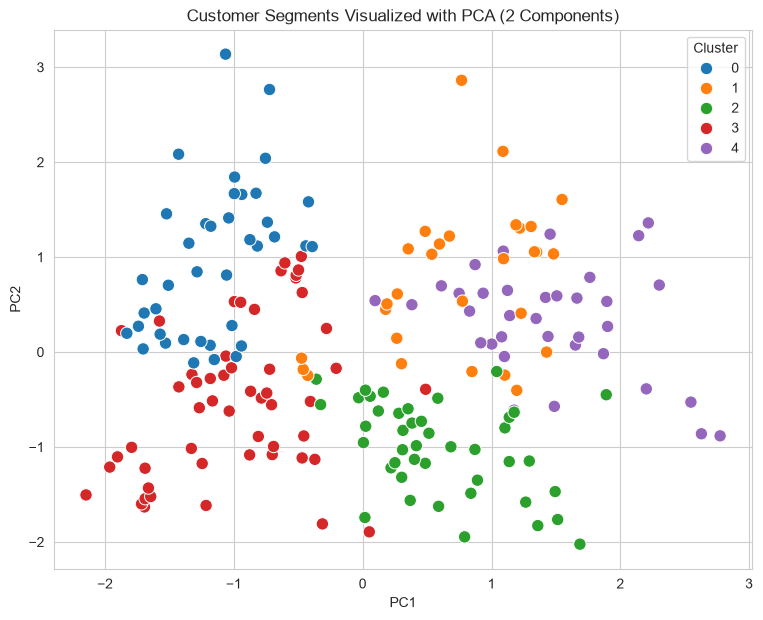

In [20]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels

plt.figure(figsize=(9,7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='tab10', s=80)
plt.title('Customer Segments Visualized with PCA (2 Components)')
plt.savefig('8_clusters_pca.png')
plt.show()

### 8.3 Explained Variance by Number of Components
Check how many components are needed to explain most of the variance.

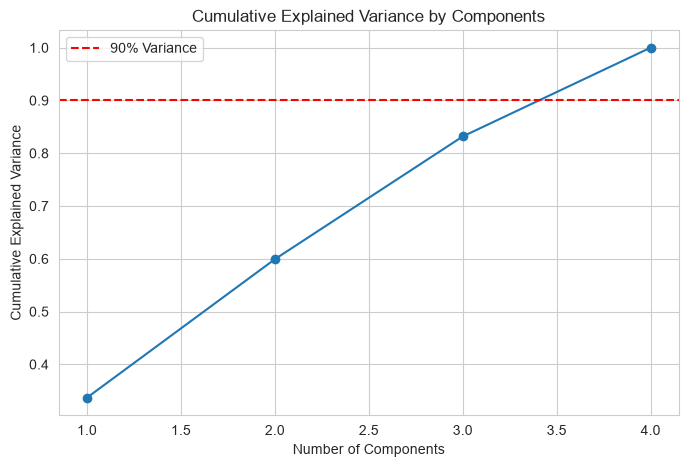

In [21]:
pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.title('Cumulative Explained Variance by Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.9, color='red', linestyle='--', label='90% Variance')
plt.legend()
plt.savefig('9_pca_cumulative_variance.png')
plt.show()

## Step 9: Analyze Cluster Profiles
Understand what each customer segment actually represents.

In [22]:
cluster_profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profile['Count'] = df['Cluster'].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,32.692308,86.538462,82.128205,39
1,36.482759,89.517241,18.000000,29
2,49.813953,49.232558,40.069767,43
3,24.907407,39.722222,61.203704,54
4,55.714286,53.685714,36.771429,35


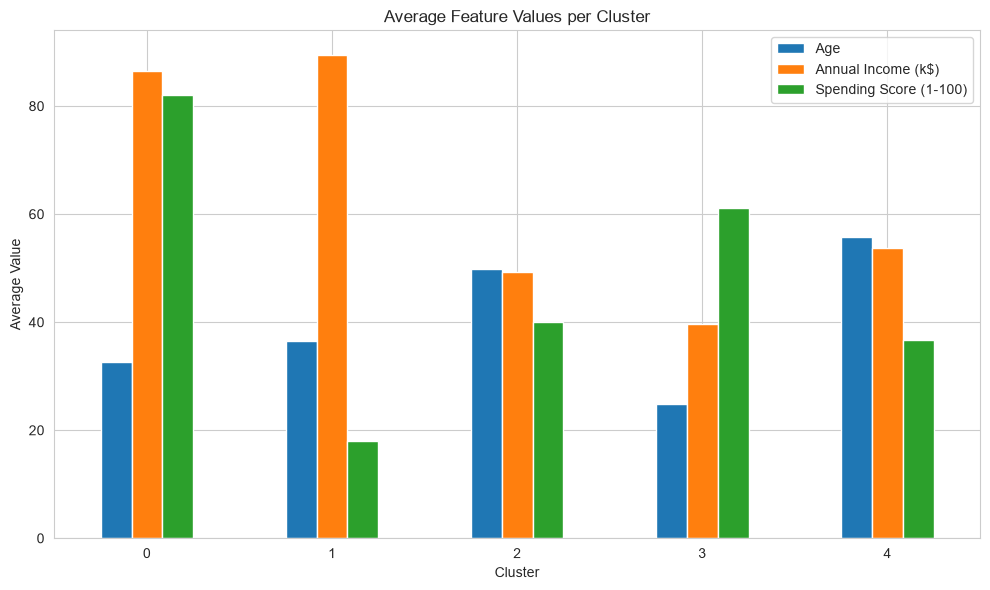

In [23]:
# Visualize cluster profiles
cluster_profile[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].plot(
    kind='bar', figsize=(10,6)
)
plt.title('Average Feature Values per Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('10_cluster_profiles.png')
plt.show()

## Step 10: Validate with Test Cases
Sanity-check the clustering by predicting the segment for a few new hypothetical customers.

In [24]:
# Example new customers: [Age, Annual Income (k$), Spending Score (1-100), Gender(0=F,1=M)]
new_customers = pd.DataFrame([
    [25, 40, 80, 0],   # Young, low income, high spender
    [45, 90, 20, 1],   # Middle-aged, high income, low spender
    [35, 60, 50, 0],   # Average across the board
], columns=features)

new_customers_scaled = scaler.transform(new_customers)
predicted_clusters = kmeans.predict(new_customers_scaled)

new_customers['Predicted Cluster'] = predicted_clusters
new_customers

,Age,Annual Income (k$),Spending Score (1-100),Gender,Predicted Cluster
0,25,40,80,0,3
1,45,90,20,1,1
2,35,60,50,0,2


## Step 11: Save Segmented Dataset

In [25]:
df.to_csv('customer_segments.csv', index=False)
print('Segmented dataset saved as customer_segments.csv')

Segmented dataset saved as customer_segments.csv
